# 消费行为分析

本笔记本聚焦客户的消费金额、频率、历史购买行为等维度，分析客户的消费模式。
- 购买金额分布情况
- 不同年龄段的平均消费水平
- 性别与消费金额的关系
- 历史购买次数与当前消费的关联

## 分析目标
揭示客户的消费能力、行为规律，为客户价值评估和精准营销提供数据支持。

## 1. 导入所需库和数据

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

# 读取数据
df = pd.read_csv('shopping_behavior_updated.csv')
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")
df.head()

数据形状: (3900, 18)
列名: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 2. 数据预处理和清洗

## 3. 购买金额分布情况

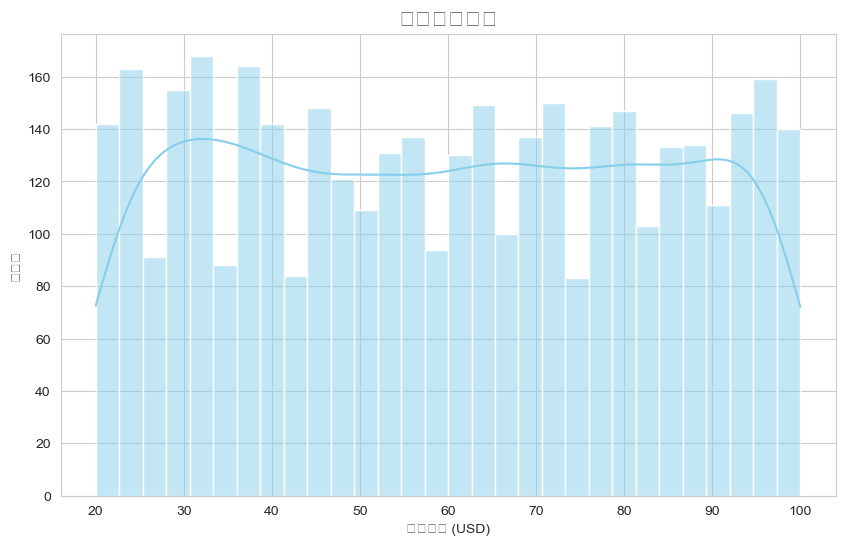

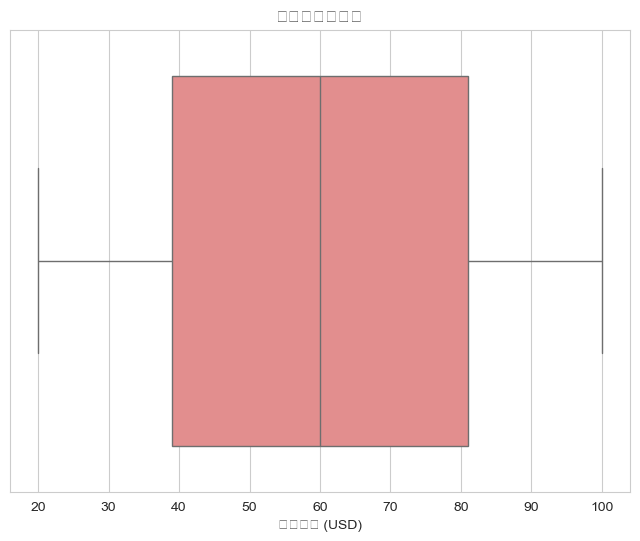

In [2]:
# 购买金额分布情况
plt.figure(figsize=(10,6))
sns.histplot(df['Purchase Amount (USD)'], bins=30, kde=True, color='skyblue')
plt.title('购买金额分布', fontsize=16)
plt.xlabel('购买金额 (USD)')
plt.ylabel('客户数')
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x=df['Purchase Amount (USD)'], color='lightcoral')
plt.title('购买金额箱线图')
plt.xlabel('购买金额 (USD)')
plt.show()

## 4. 不同年龄段的平均消费水平

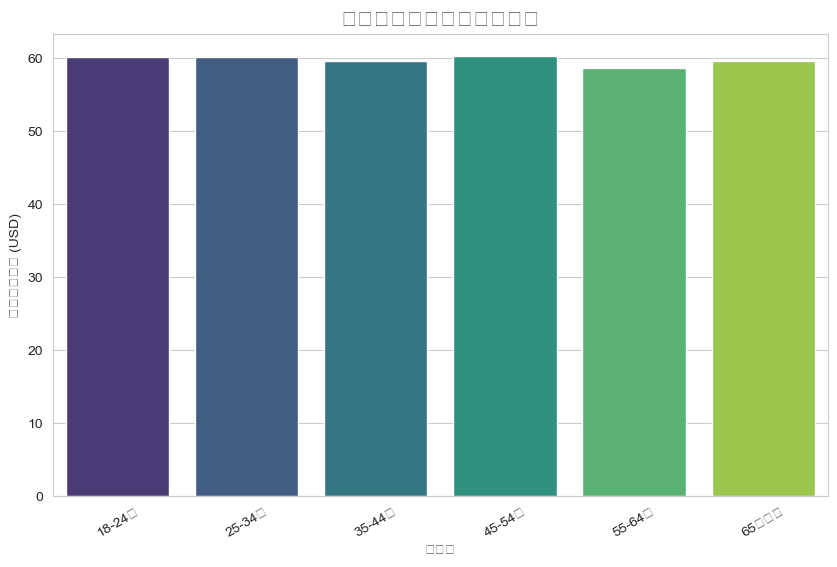

In [3]:
# 创建年龄段分组
def create_age_groups(age):
    if age < 25:
        return '18-24岁'
    elif age < 35:
        return '25-34岁'
    elif age < 45:
        return '35-44岁'
    elif age < 55:
        return '45-54岁'
    elif age < 65:
        return '55-64岁'
    else:
        return '65岁以上'
df['Age_Group'] = df['Age'].apply(create_age_groups)

# 不同年龄段的平均消费水平
age_avg = df.groupby('Age_Group')['Purchase Amount (USD)'].mean().round(2)
plt.figure(figsize=(10,6))
sns.barplot(x=age_avg.index, y=age_avg.values, palette='viridis')
plt.title('不同年龄段的平均消费金额', fontsize=16)
plt.xlabel('年龄段')
plt.ylabel('平均消费金额 (USD)')
plt.xticks(rotation=30)
plt.show()

## 5. 性别与消费金额的关系

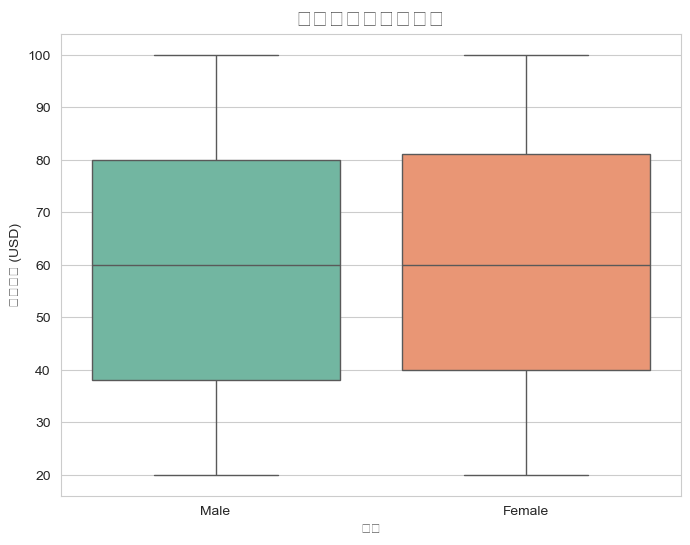

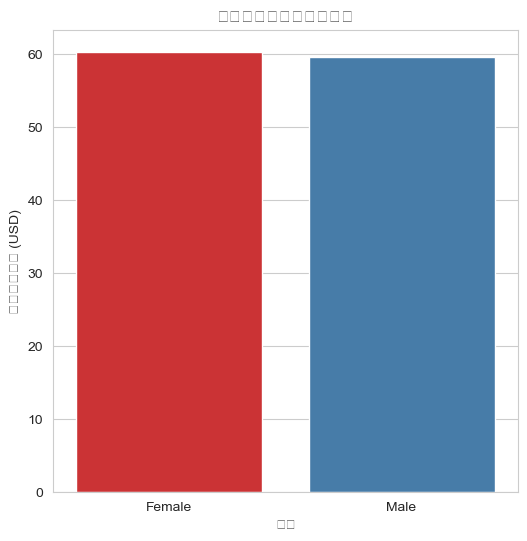

In [4]:
# 性别与消费金额的关系
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='Purchase Amount (USD)', data=df, palette='Set2')
plt.title('性别与消费金额分布', fontsize=16)
plt.xlabel('性别')
plt.ylabel('消费金额 (USD)')
plt.show()

# 平均消费金额
gender_avg = df.groupby('Gender')['Purchase Amount (USD)'].mean().round(2)
plt.figure(figsize=(6,6))
sns.barplot(x=gender_avg.index, y=gender_avg.values, palette='Set1')
plt.title('不同性别的平均消费金额')
plt.xlabel('性别')
plt.ylabel('平均消费金额 (USD)')
plt.show()

## 6. 历史购买次数与当前消费的关联

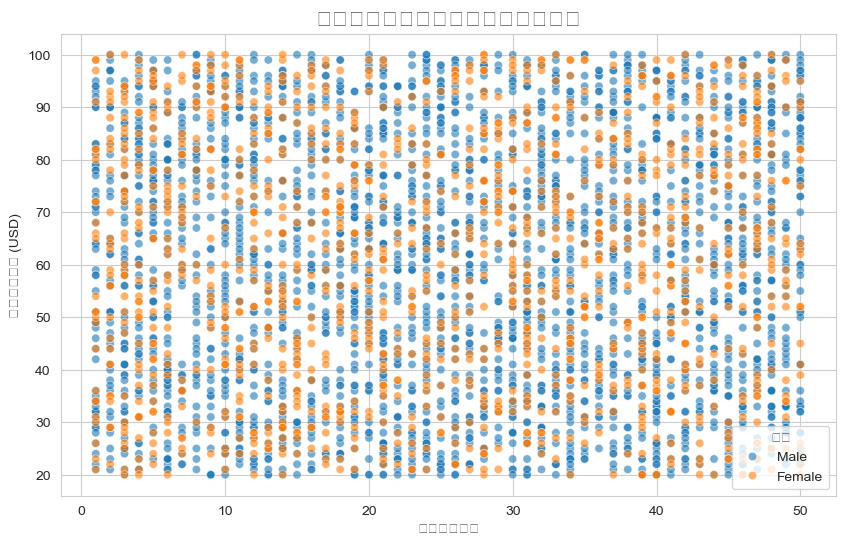

历史购买次数与当前消费金额的相关系数: 0.01


In [5]:
# 历史购买次数与当前消费的关联
plt.figure(figsize=(10,6))
sns.scatterplot(x='Previous Purchases', y='Purchase Amount (USD)', data=df, hue='Gender', alpha=0.6)
plt.title('历史购买次数与当前消费金额的关系', fontsize=16)
plt.xlabel('历史购买次数')
plt.ylabel('当前消费金额 (USD)')
plt.legend(title='性别')
plt.show()

# 相关性分析
corr = df[['Previous Purchases', 'Purchase Amount (USD)']].corr().iloc[0,1]
print(f"历史购买次数与当前消费金额的相关系数: {corr:.2f}")

## 7. 主要发现与结论

- 购买金额分布呈右偏，部分客户高消费。
- 不同年龄段的平均消费水平差异明显，部分年龄段消费能力突出。
- 性别对消费金额有一定影响，需结合业务实际进一步分析。
- 历史购买次数与当前消费金额存在一定相关性，忠诚客户价值较高。

*建议结合客户分层和精准营销策略，提升客户价值和复购率。*